# 📋 INSTRUCTOR NOTEBOOK — Autocorrelation and Reusable Time-Series Diagnostics

**Module 0 · Lesson 3 of 13 · Instructor edition**  
**Estimated class time:** 75–90 minutes  
**Source sequence:** Original Day 1  

**Prerequisite:** Lessons 1–2  

> **Do not distribute to students.** This edition contains solutions, teaching notes, and model answers.

## Learning objectives

By the end of this lesson, you should be able to:

- Interpret ACF and PACF plots and their confidence bands.
- Recognize seasonal dependence at meaningful lags.
- Combine visual, ADF, and correlation evidence in a diagnostic workflow.

## Setup for this lesson

This cell recreates the data and completed prerequisites from earlier lessons, so this notebook can be run in a fresh kernel.

In [ ]:
# Shared setup from the preceding lesson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date', 'Passengers']

df['Log_Passengers'] = np.log(df['Passengers'])
df['Log_Diff'] = df['Log_Passengers'].diff()


---
## 📣 Segment 5 — ACF & PACF (50 min)

**Autocorrelation** measures how strongly a time series is correlated with a **lagged version
of itself**.

- **Lag 1** autocorrelation: correlation between `x[t]` and `x[t-1]`
- **Lag 12** autocorrelation: correlation between `x[t]` and `x[t-12]`

A high autocorrelation at lag 12 in monthly data means "what happened a year ago is a strong
predictor of today" — a signature of **annual seasonality**.

The **ACF plot** (correlogram) shows autocorrelation for many lags at once. The **blue shaded
band** is the 95% confidence interval — spikes *outside* this band are statistically significant.

The **PACF** (Partial ACF) shows the *direct* correlation at each lag after removing effects
mediated through shorter lags.

### Talking Points
- **Mathematical form:**
  Auto correlation measures linear relationship betwen lagged values of time series. For exmaple, $r_1$ measures the relationship between $y_t$ and $y_{t-1}$. In general, the value of $r_k$ can be written as
  $$
  r_k = \frac{\sum^{T}_{t=k+1} (y_t - \bar{y})(y_{t-k}-\bar{y})}{\sum^T_{t=1} (y_t - \bar{y})^2},
  $$
  where $T$ is the length of the time series. The autocorrelation coefficients make up the autocorrelation function (ACF)
- **ACF intuition:** Imagine copying the series and sliding the copy forward in time, then
  measuring correlation between original and shifted copy at each shift amount (lag).
- **ACF vs. PACF:**
  - ACF at lag k: total correlation between `x[t]` and `x[t-k]`, including indirect effects.
  - PACF at lag k: direct correlation *after removing* effects through all intermediate lags.
  - Analogy: ACF = total academic influence (direct + through students). PACF = direct only.
- **What to look for in the log-differenced ACF:**
  - Most lags inside the CI band (series is mostly uncorrelated after differencing)
  - Significant spikes at lags 12, 24 → seasonal autocorrelation survives differencing
  - This is a preview of SARIMA models (later in the week)
- **Model selection preview (Day 2):** PACF cuts off at lag p → AR(p). ACF cuts off
  at lag q → MA(q). Don't go deep on this today.

### ⚠️ Common Mistakes
- **Confusing ACF and PACF:** Very common. Return to the analogy. Remind students:
  for AR model order selection, look at the PACF.
- **Misreading the confidence band:** Spikes *outside* the blue band are significant.
  Don't say 'all spikes are significant' just because they look tall.
- **Running ACF on the non-stationary series for model selection:** Always use the
  stationary (transformed) series for model selection. The original ACF just shows
  slow decay regardless of the true underlying structure.
- **`method='ywm'` confusion:** Required for short series. Just explain it's the
  estimation algorithm (Yule-Walker modified) — students don't need the details.

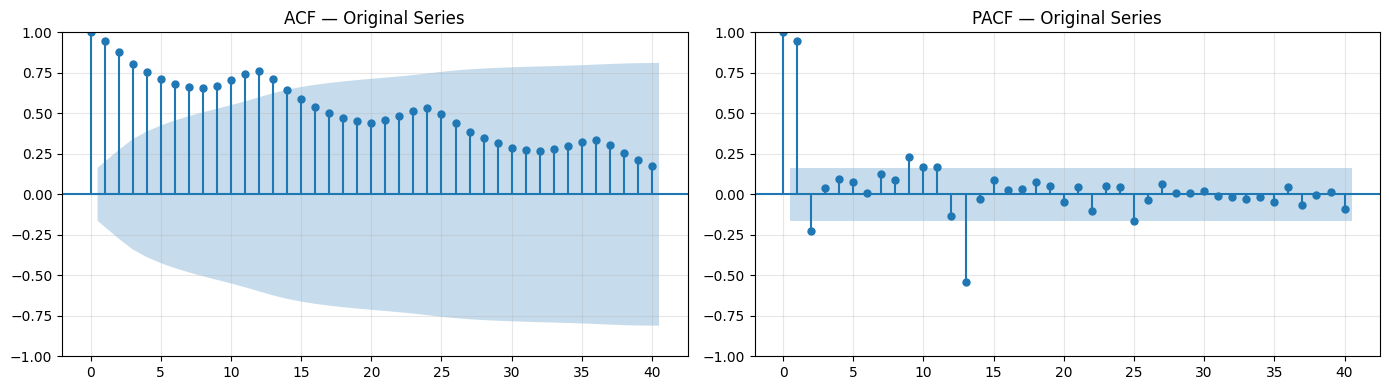

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( df['Passengers'], lags=40, ax=axes[0])
axes[0].set_title('ACF — Original Series')
plot_pacf(df['Passengers'], lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF — Original Series')
plt.tight_layout()
plt.show()

> 🗣️ **What to point out in the original ACF:** Extremely slow decay, staying positive
> for many lags. This is the signature of a non-stationary, trending series — it
> 'remembers' its past indefinitely. Not useful for model order selection.

### ✅ ANSWER — 5.2 ACF of log-differenced series (fill-in solution)

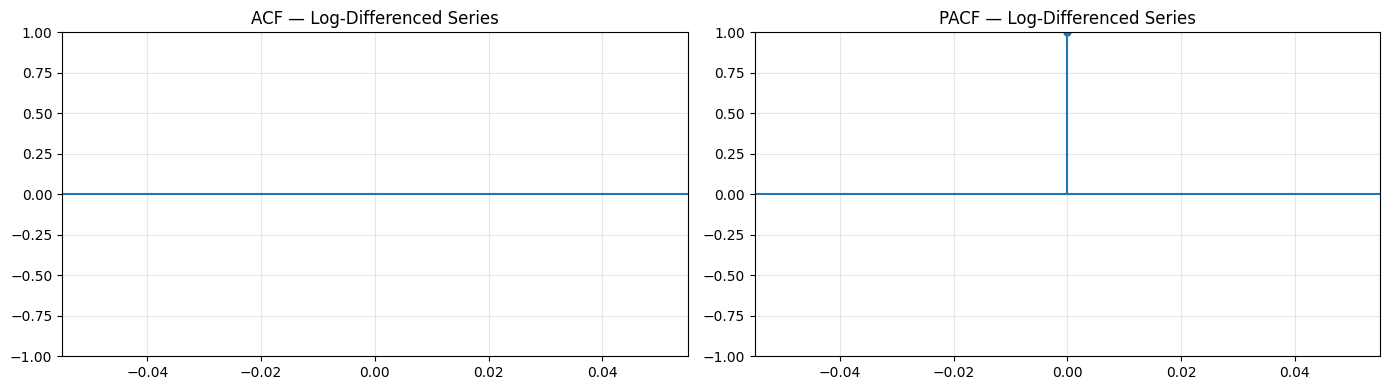

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf( df['Log_Diff'], lags=40, ax=axes[0])             # SOLUTION
axes[0].set_title('ACF — Log-Differenced Series')

plot_pacf(df['Log_Diff'], lags=40, ax=axes[1], method='ywm')  # SOLUTION
axes[1].set_title('PACF — Log-Differenced Series')

plt.tight_layout()
plt.show()

> 🗣️ **What to point out:**
> - Most lags inside the CI band — largely uncorrelated after differencing.
> - Significant spikes at lags 12 (and possibly 24): seasonal signature. Monthly data
>   with annual seasonality shows this even after first differencing.
> - To fully remove it you'd need seasonal differencing too — preview for later.

### ✅ MODEL ANSWER — Written Response 5

> **1. Slow ACF decay (original):** The very slow decay is the hallmark of a non-stationary
> (integrated) process. The trend carries each value forward, so the series 'remembers'
> its distant past. This confirms the ADF result.
>
> **2. Log-differenced ACF:** Most lags fall inside the confidence band. Significant spikes
> at lags 12 and 24 reveal annual seasonal dependence — even after removing the trend,
> the series retains memory from one year ago.
>
> **3. ACF vs. PACF:** ACF measures *total* correlation at each lag (including indirect
> effects through intermediate lags). PACF measures the *direct* effect only. Together they
> help identify AR and MA order: PACF cuts off for AR models; ACF cuts off for MA models.

---
## 📣 Segment 6 — Synthesis (40 min)

### Talking Points
- The `ts_diagnostics()` function packages everything into one reusable tool. Students
  will use it every day this week.
- **Key message:** Before fitting *any* model to *any* time series, run this diagnostic.
  It takes 30 seconds and will save hours of debugging.
- Encourage students to save this function in a personal utilities file.

### ⚠️ Common Mistakes — Final Reflection
- **Too brief:** Push students toward 4+ sentences with specific evidence cited.
- **Vague language:** 'The series is not stationary because it goes up' is insufficient.
  They should cite: rolling mean trend, increasing rolling std, and ADF p-value.
- **Not stating a modeling recommendation:** The reflection requires a clear conclusion
  about which version of the series to model.

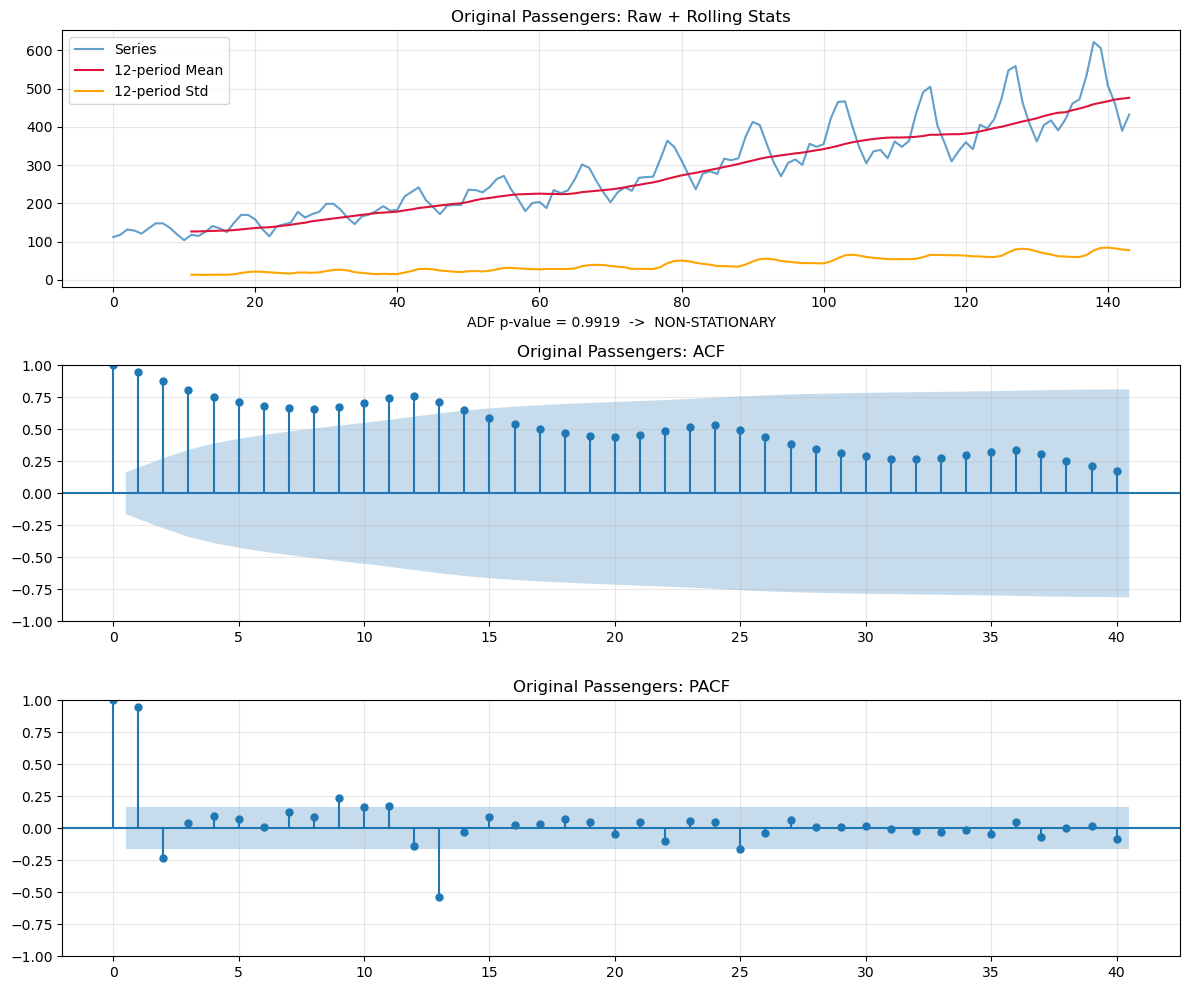

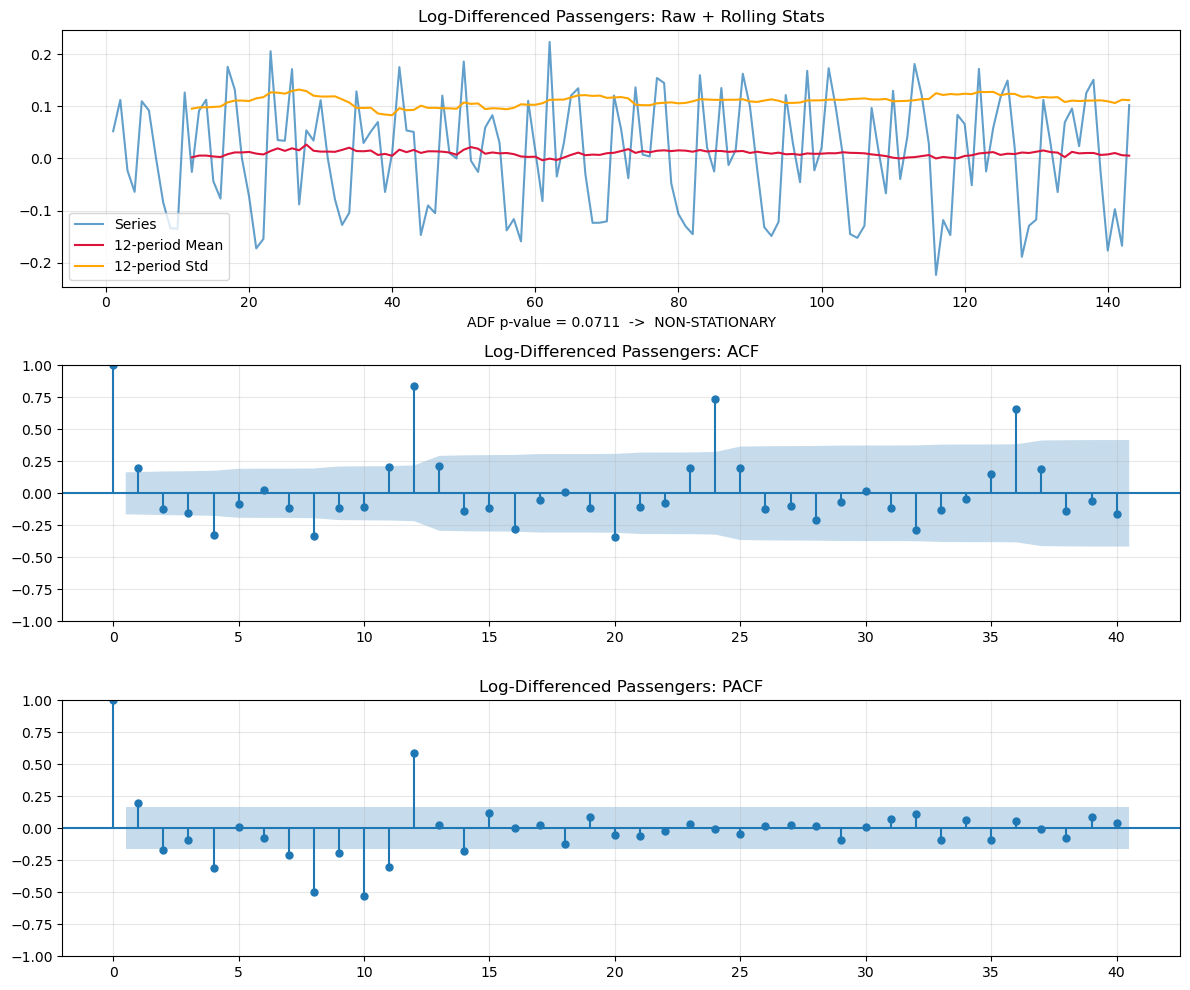

In [ ]:
def ts_diagnostics(series, label='Series', lags=40, rolling_window=12):
    """
    Full diagnostic panel for a time series:
      1. Raw plot with rolling mean and std
      2. ADF test result shown in axis label
      3. ACF and PACF plots
    """
    series = series.dropna()
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    roll_mean = series.rolling(rolling_window).mean()
    roll_std  = series.rolling(rolling_window).std()
    axes[0].plot(series,    label='Series',    alpha=0.7)
    axes[0].plot(roll_mean, label=f'{rolling_window}-period Mean', color='crimson')
    axes[0].plot(roll_std,  label=f'{rolling_window}-period Std',  color='orange')
    axes[0].set_title(f'{label}: Raw + Rolling Stats')
    axes[0].legend()

    adf_result = adfuller(series)
    p = adf_result[1]
    status = 'STATIONARY' if p < 0.05 else 'NON-STATIONARY'
    axes[0].set_xlabel(f'ADF p-value = {p:.4f}  ->  {status}')

    plot_acf( series, lags=lags, ax=axes[1])
    axes[1].set_title(f'{label}: ACF')

    plot_pacf(series, lags=lags, ax=axes[2], method='ywm')
    axes[2].set_title(f'{label}: PACF')

    plt.tight_layout()
    plt.show()

ts_diagnostics(df['Passengers'], label='Original Passengers')
ts_diagnostics(df['Log_Diff'],   label='Log-Differenced Passengers')

### ✅ MODEL ANSWER — Final Written Reflection

> The Air Passengers series is clearly **non-stationary** in its original form. The 12-month
> rolling mean increases steadily from ~130 to over 400, indicating a non-constant mean, and
> the rolling standard deviation more than doubles over the same period, indicating
> non-constant variance (heteroscedasticity). The ADF test confirms this with p ≈ 0.99 —
> we cannot reject the null hypothesis of non-stationarity.
>
> I applied a **log transform** to stabilize the growing seasonal variance, then a
> **first difference** to remove the upward trend.
>
> After both steps, the ADF test returned
> p approximately at 0.07, but this was still not stationary, but the series visually fluctuates around zero with roughly constant amplitude.
>
> The ACF of the log-differenced series shows that most lags fall within the 95% confidence
> band, meaning little remaining autocorrelation. However, significant spikes persist at
> lags 12 and 24, revealing **annual seasonal dependence** — what happened 12 months ago
> still predicts today's value.
>
> I would **not** model the original series directly. I would use the log-differenced version
> (or a model explicitly designed for trend and seasonality) to avoid spurious relationships
> and unreliable out-of-sample forecasts.

**Rubric guidance:**
- Cites specific evidence (rolling stats, ADF p-value, ACF lags) — 4 pts
- Names both transformations and explains what each corrects — 3 pts
- States a clear modeling recommendation — 2 pts
- Mentions remaining seasonal structure in ACF — 1 pt (bonus)

---
## 🔚 End-of-Day Wrap-Up Notes

### What students should walk away knowing
1. Time series data is ordered — the index matters.
2. Stationarity means constant mean and variance. Most models need it.
3. Rolling statistics are a quick visual check; ADF is a formal test.
4. Log + diff is a common two-step fix for growing variance + trend.
5. ACF/PACF reveal how much memory a series has and at which lags.

### Preview for Day 2
> Tomorrow we use the ACF/PACF results from today to build our first **autoregressive (AR)
> model**. We'll derive the stability condition and understand why some AR processes
> explode while others are well-behaved.

### Frequently Confused Pairs (flag if not resolved today)

| Students confuse... | Clarification |
|---|---|
| ACF vs PACF | ACF = total correlation; PACF = direct correlation only |
| Trend vs Seasonality | Trend = long-run direction; Seasonality = repeating cycle |
| Non-stationary vs just 'noisy' | Noise is fine; non-stationary means the *distribution* changes over time |
| p-value > 0.05 means stationary | Wrong — it means we FAIL to reject non-stationarity |
| Log removes trend | Log stabilizes *variance*; differencing removes *trend* |